# LiH compiled ansatz (FIG. 13)

Six-qubit `CZ` / `H` / `RX` circuit. **FIG. 10** prep is unchanged (includes `X` on `q0` and `q3` after the CNOT chain). The three `RX` gates on `q[1]` use separate symbols $\theta_1,\theta_2,\theta_3$ (paper-style). With **all three set to 0**, those rotations are identity.

**HF check:** On the **exported active-space Pauli Hamiltonian**, restricted HF is the computational ket **|100100⟩**, i.e. **only** `X` on `LineQubit(0)` and `LineQubit(3)`. The compiled FIG. 13 depth **does not** preserve that ket, so `⟨H⟩` at $\theta_i=0$ on the full circuit will **not** in general equal bare-RHF `⟨H⟩`. The next cell prints both the compiled value and the reference from `X(q0), X(q3)` alone.

**Noise:** Gate-only depolarizing via `GateArityDepolarizingNoise` (density-matrix `Tr[Hρ]`). Later cells add **finite-shot** energy (**OGM**, readout `p_0_success` / `p_1_success`, **REM**) and optional **CDR** calibration on near-Clifford training circuits (needs the same OGM + `SHADOWGROUPING_ROOT`).

0: ───X───Rx(0.5π)───@──────────────────────────────@───────@─────────────────────────────────────────────────────────────────────────@───Rx(-0.5π)───
                     │                              │       │                                                                         │
1: ──────────────────@───────────@───Rx(0.2π)───@───@───H───@───@───@───Rx(0.2π)───@───────────────────────────@───Rx(0.2π)───@───@───@───H───────────
                                 │              │               │   │              │                           │              │   │
2: ───H──────────────────────────┼──────────────┼───────────────@───┼──────────────┼───────────────────────────┼──────────────┼───@───H───────────────
                                 │              │                   │              │                           │              │
3: ───X───H──────────@───────────┼──────────────┼───────────────────┼──────────────┼───────────@───────@───────┼──────────────┼───────@───H───────────


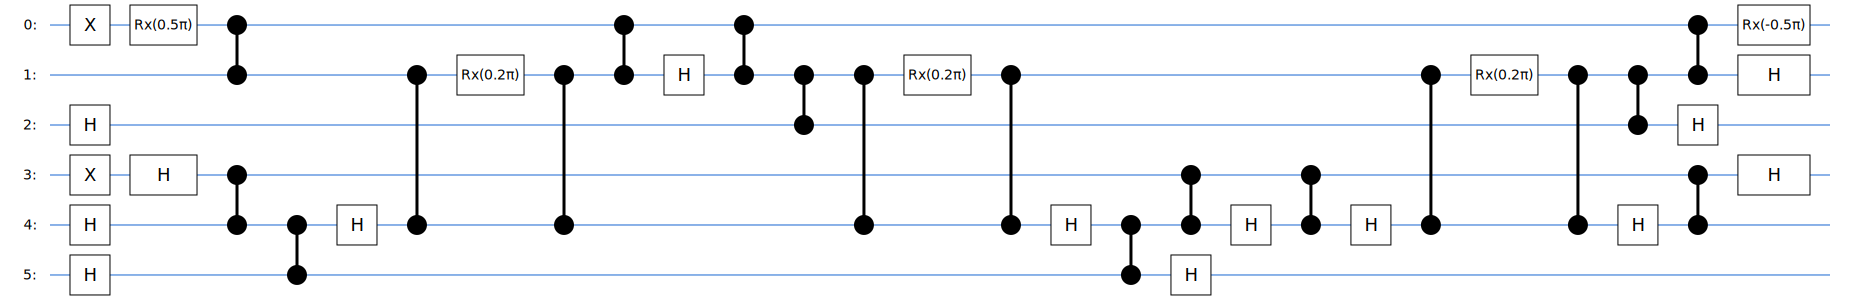

In [1]:
from __future__ import annotations

import cirq
import numpy as np
from cirq.ops import GlobalPhaseGate

# Needed for text/SVG diagrams: top-level ``cirq.GlobalPhaseGate`` can be missing in some kernels.
setattr(cirq, "GlobalPhaseGate", GlobalPhaseGate)

import sympy
from IPython.display import display

from cirq.contrib.svg import SVGCircuit


def lih_fig13_circuit(
    theta1: sympy.Symbol, theta2: sympy.Symbol, theta3: sympy.Symbol
) -> tuple[cirq.Circuit, list[cirq.LineQubit]]:
    """Compiled LiH ansatz (FIG. 13): three independent ``RX`` angles on ``q[1]``.

    FIG. 10 initial prep (paper): ``R_y(π/5)``, CNOT chain, then ``X`` on ``q0`` and ``q3``.
    """
    q = cirq.LineQubit.range(6)
    q0, q1, q2, q3, q4, q5 = q
    c = cirq.Circuit()
    c.append(cirq.X(q0))
    c.append(cirq.X(q3))

    c.append(cirq.rx(np.pi / 2).on(q0))
    c.append(cirq.H(q2))
    c.append(cirq.H(q3))
    c.append(cirq.H(q4))
    c.append(cirq.H(q5))

    c.append([cirq.CZ(q0, q1), cirq.CZ(q3, q4)])
    c.append([cirq.CZ(q4, q5), cirq.H(q4)])

    c.append(cirq.CZ(q1, q4))
    c.append(cirq.rx(theta1).on(q1))
    c.append(cirq.CZ(q1, q4))

    c.append(cirq.CZ(q0, q1))
    c.append(cirq.H(q1))
    c.append(cirq.CZ(q0, q1))
    c.append(cirq.CZ(q1, q2))

    c.append(cirq.CZ(q1, q4))
    c.append(cirq.rx(theta2).on(q1))
    c.append(cirq.CZ(q1, q4))

    c.append(cirq.H(q4))
    c.append(cirq.CZ(q4, q5))
    c.append(cirq.H(q5))
    c.append(cirq.CZ(q3, q4))
    c.append(cirq.H(q4))
    c.append(cirq.CZ(q3, q4))
    c.append(cirq.H(q4))

    c.append(cirq.CZ(q1, q4))
    c.append(cirq.rx(theta3).on(q1))
    c.append(cirq.CZ(q1, q4))

    c.append(cirq.H(q4))
    c.append(cirq.CZ(q1, q2))
    c.append(cirq.H(q2))
    c.append(cirq.CZ(q0, q1))
    c.append(cirq.CZ(q3, q4))
    c.append(cirq.rx(-np.pi / 2).on(q0))
    c.append([cirq.H(q1), cirq.H(q3)])

    return c, q


theta1 = sympy.Symbol("theta1")
theta2 = sympy.Symbol("theta2")
theta3 = sympy.Symbol("theta3")
circuit, qubits = lih_fig13_circuit(theta1, theta2, theta3)

# Diagram with θ₁ = θ₂ = θ₃ = π/5 (paper-style visualization). HF check uses all zeros in the next cell.
_theta_viz = np.pi / 5
resolver_viz = cirq.ParamResolver({theta1: _theta_viz, theta2: _theta_viz, theta3: _theta_viz})
circuit_draw = cirq.resolve_parameters(circuit, resolver_viz)

print(circuit_draw)
display(SVGCircuit(circuit_draw))

In [2]:
import sys
from pathlib import Path

# Repo imports: Hamiltonian matches ``generate_lih_hamiltonian_paper_lih`` export layout.
_repo = Path.cwd().resolve()
if not (_repo / "main_cursor_lib.py").is_file():
    _repo = _repo.parent
sys.path.insert(0, str(_repo))
sys.path.insert(0, str(_repo / "test_LiH_case"))

from generate_lih_hamiltonian_paper_lih import build_paper_lih_hamiltonian
from main_cursor_lib import qubit_operator_to_pauli_sum

bond_length = 2.2

# θ₁ = θ₂ = θ₃ = 0 → the three ``RX`` gates on ``q1`` are identity; FIG. 10 + FIG. 13 still apply other gates.
resolver = cirq.ParamResolver({theta1: 0.0, theta2: 0.0, theta3: 0.0})
resolved = cirq.resolve_parameters(circuit, resolver)

sim = cirq.Simulator()
result = sim.simulate(resolved, qubit_order=qubits)
psi = np.asarray(result.final_state_vector, dtype=np.complex128)

print(f"qubits: {len(qubits)}  state_dim: {len(psi)}")
assert len(psi) == 2 ** len(qubits)

h_op, meta = build_paper_lih_hamiltonian(bond_length)
pauli_sum = qubit_operator_to_pauli_sum(h_op, list(qubits))
qubit_map = {q: i for i, q in enumerate(qubits)}
e_compiled = float(np.real(pauli_sum.expectation_from_state_vector(psi, qubit_map=qubit_map)))

# Reference: active-space ⟨H⟩ on spin-block RHF ket |100100⟩ = X on q0 and q3 only (no FIG. 10 / FIG. 13).
psi_hf = cirq.Simulator().simulate(
    cirq.Circuit(cirq.X(qubits[0]), cirq.X(qubits[3])),
    qubit_order=qubits,
).final_state_vector
e_hf_ref = float(
    np.real(pauli_sum.expectation_from_state_vector(np.asarray(psi_hf, dtype=np.complex128), qubit_map=qubit_map))
)

print(f"\nLiH bond {bond_length} Å")
print(f"⟨H⟩ compiled FIG. 10 + FIG. 13 with θ₁=θ₂=θ₃=0: {e_compiled:.10f} Eh")
print(f"⟨H⟩ reference |100100⟩ (X on LineQubit(0) and LineQubit(3) only): {e_hf_ref:.10f} Eh")
print(f"(PySCF total RHF energy in meta, not active-space ⟨H⟩: {meta['rhf_energy']:.10f} Eh)")

qubits: 6  state_dim: 64

LiH bond 2.2 Å
⟨H⟩ compiled FIG. 10 + FIG. 13 with θ₁=θ₂=θ₃=0: -7.8079943693 Eh
⟨H⟩ reference |100100⟩ (X on LineQubit(0) and LineQubit(3) only): -7.8079943693 Eh
(PySCF total RHF energy in meta, not active-space ⟨H⟩: -7.8079943693 Eh)


In [3]:
# Evaluate FIG. 13 compiled ansatz energy at params = [0.0, 0.07, 0.0].
params = np.array([0.0, 0.07, 0.0], dtype=float)
resolver_test = cirq.ParamResolver({theta1: params[0], theta2: params[1], theta3: params[2]})

resolved_test = cirq.resolve_parameters(circuit, resolver_test)
psi_test = np.asarray(
    cirq.Simulator().simulate(resolved_test, qubit_order=qubits).final_state_vector,
    dtype=np.complex128,
)
e_test = float(np.real(pauli_sum.expectation_from_state_vector(psi_test, qubit_map=qubit_map)))

print(f"params = {params.tolist()}")
print(f"E(params) = {e_test:.10f} Eh")

params = [0.0, 0.07, 0.0]
E(params) = -7.8087122206 Eh


In [4]:
# Noisy energy: ``GateArityDepolarizingNoise`` adds single-qubit depolarizing channels after
# each gate — 2Q gates → ``two_qubit_depol_prob`` on both lines; 1Q gates → ``one_qubit_depol_prob``.
# No measurement noise here (density matrix + Tr[H ρ]).
import sys
from pathlib import Path

_repo = Path.cwd().resolve()
if not (_repo / "main_cursor_lib.py").is_file():
    _repo = _repo.parent
for _p in (str(_repo), str(_repo / "test_LiH_case")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from main_cursor_lib_test_LiH import (
    GateArityDepolarizingNoise,
    ONE_QUBIT_GATE_DEPOL_PROB,
    TWO_QUBIT_GATE_DEPOL_PROB,
    trace_energy,
)

random_seed = 1234

gate_noise = GateArityDepolarizingNoise(
    two_qubit_depol_prob=TWO_QUBIT_GATE_DEPOL_PROB,
    one_qubit_depol_prob=ONE_QUBIT_GATE_DEPOL_PROB,
)
noisy_ansatz = circuit.with_noise(gate_noise)
resolver_noisy = cirq.ParamResolver(
    {theta1: float(params[0]), theta2: float(params[1]), theta3: float(params[2])}
)
resolved_noisy = cirq.resolve_parameters(noisy_ansatz, resolver_noisy)

rho_noisy = np.asarray(
    cirq.DensityMatrixSimulator(seed=random_seed)
    .simulate(resolved_noisy, qubit_order=qubits)
    .final_density_matrix,
    dtype=np.complex128,
)

hamiltonian_matrix = pauli_sum.matrix(qubits=qubits)
trace_noisy_energy = trace_energy(hamiltonian_matrix, rho_noisy)

print(
    f"noise: two_qubit_depol={gate_noise.two_qubit_depol_prob} "
    f"one_qubit_depol={gate_noise.one_qubit_depol_prob}"
)
print(f"params = {params.tolist()}")
print(f"Tr[H ρ_noisy] (gate noise only): {trace_noisy_energy:.10f} Eh")

noise: two_qubit_depol=0.015 one_qubit_depol=0.0015
params = [0.0, 0.07, 0.0]
Tr[H ρ_noisy] (gate noise only): -7.7154719391 Eh


In [5]:
# Finite-shot energy from the same ``rho_noisy`` as above: OGM measurement layout + asymmetric
# readout (``p_0_success`` / ``p_1_success`` on LineQubit 0…5) and optional REM in post-processing.
# Requires ``shadowgrouping`` OGM text for LiH at ``bond_length``; adjust ``SHADOWGROUPING_ROOT`` if needed.
import sys
from pathlib import Path

_repo = Path.cwd().resolve()
if not (_repo / "main_cursor_lib.py").is_file():
    _repo = _repo.parent
for _p in (str(_repo), str(_repo / "test_LiH_case")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from shot_measurement_test_LiH import estimate_energy_from_noisy_rho_shots

num_shots = 81920
measurement_scheme = "ogm"
sampling_seed = 1234
epsilon = 0.1

p_0_success = np.array([0.9756, 0.9748, 0.9738, 0.9656, 0.9585, 0.9514])
p_1_success = np.array([0.9756, 0.9748, 0.9738, 0.9656, 0.9585, 0.9514])

apply_readout_noise = True
apply_rem = True

SHADOWGROUPING_ROOT = "/Users/zacharyhe/shadowgrouping"
ogm_file = Path(
    f"{SHADOWGROUPING_ROOT}/haozhaowu/LiH/hamil_class/ogm_outputs/OGM_ogm_LiH_{bond_length:.1f}.txt"
)

print(f"OGM file: {ogm_file}  exists={ogm_file.is_file()}")

if not ogm_file.is_file():
    print(
        "Skip OGM shot estimate: OGM file missing. Generate LiH OGM at this bond or set SHADOWGROUPING_ROOT."
    )
elif not Path(SHADOWGROUPING_ROOT).is_dir():
    print("Skip OGM shot estimate: SHADOWGROUPING_ROOT does not exist.")
else:
    shot_est = estimate_energy_from_noisy_rho_shots(
        rho_noisy,
        pauli_sum,
        qubits,
        num_shots=num_shots,
        measurement_scheme=measurement_scheme,
        p_0_success=p_0_success,
        p_1_success=p_1_success,
        apply_rem=apply_rem,
        apply_readout_noise=apply_readout_noise,
        sampling_seed=sampling_seed,
        epsilon=epsilon,
        ogm_file=ogm_file,
        shadowgrouping_root=SHADOWGROUPING_ROOT,
    )
    eu = float(shot_est["energy_unmitigated"])
    er = float(shot_est["energy_rem"])
    print(f"Finite-shot energy (readout noise, no REM correction): {eu:.12f} Eh")
    print(f"Finite-shot energy (REM readout mitigation):          {er:.12f} Eh")
    print(f"REM delta (REM - raw shots):                            {er - eu:.12f} Eh")
    print(
        f"\nReference Tr[H ρ] (same ρ, exact Pauli from DM; no shot noise): {trace_noisy_energy:.12f} Eh"
    )

OGM file: /Users/zacharyhe/shadowgrouping/haozhaowu/LiH/hamil_class/ogm_outputs/OGM_ogm_LiH_2.2.txt  exists=True
Finite-shot energy (readout noise, no REM correction): -7.676463381899 Eh
Finite-shot energy (REM readout mitigation):          -7.701141020488 Eh
REM delta (REM - raw shots):                            -0.024677638589 Eh

Reference Tr[H ρ] (same ρ, exact Pauli from DM; no shot noise): -7.715471939077 Eh


In [ ]:
# CDR: near-Clifford training from ``main_cursor_lib_test_LiH.generate_near_clifford_param_sets``
# (``theta1``…``theta3`` snapping is supported in ``clifford_snap_value_for_symbol``).
import sys
from pathlib import Path

_repo = Path.cwd().resolve()
if not (_repo / "main_cursor_lib.py").is_file():
    _repo = _repo.parent
for _p in (str(_repo), str(_repo / "test_LiH_case")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import numpy as np

from main_cursor_lib_test_LiH import (
    ONE_QUBIT_GATE_DEPOL_PROB,
    TWO_QUBIT_GATE_DEPOL_PROB,
    generate_near_clifford_param_sets,
)
from shot_measurement_test_LiH import apply_cdr_models, estimate_energy_from_noisy_rho_shots, train_cdr_models

if "num_shots" not in globals():
    num_shots = 8192
if "epsilon" not in globals():
    epsilon = 0.1
if "sampling_seed" not in globals():
    sampling_seed = 1234
if "apply_readout_noise" not in globals():
    apply_readout_noise = True
if "p_0_success" not in globals():
    p_0_success = np.array([0.9756, 0.9748, 0.9738, 0.9656, 0.9585, 0.9514])
    p_1_success = np.array([0.9756, 0.9748, 0.9738, 0.9656, 0.9585, 0.9514])
if "measurement_scheme" not in globals():
    measurement_scheme = "ogm"
if "SHADOWGROUPING_ROOT" not in globals():
    SHADOWGROUPING_ROOT = "/Users/zacharyhe/shadowgrouping"
if "ogm_file" not in globals():
    ogm_file = Path(
        f"{SHADOWGROUPING_ROOT}/haozhaowu/LiH/hamil_class/ogm_outputs/OGM_ogm_LiH_{bond_length:.1f}.txt"
    )

noise_params_cdr = {
    "two_qubit_depol_prob": TWO_QUBIT_GATE_DEPOL_PROB,
    "one_qubit_depol_prob": ONE_QUBIT_GATE_DEPOL_PROB,
}

symbols_li_h = [theta1, theta2, theta3]
target_params_cd = {theta1: float(params[0]), theta2: float(params[1]), theta3: float(params[2])}
_cdr_sim_seed = int(globals().get("random_seed", 1234))

if not ogm_file.is_file() or not Path(SHADOWGROUPING_ROOT).is_dir():
    print("Skip CDR: need valid ogm_file and SHADOWGROUPING_ROOT (same as OGM shot cell).")
else:
    training_resolvers = generate_near_clifford_param_sets(
        target_params_cd,
        symbols_li_h,
        num_circuits=12,
        t_max=2,
        circuit=circuit,
        min_snap_fraction=0.25,
        seed=42,
    )
    cdr_models = train_cdr_models(
        circuit,
        pauli_sum,
        qubits,
        training_resolvers,
        noise_params=noise_params_cdr,
        simulator_seed=_cdr_sim_seed,
        num_shots=num_shots,
        measurement_scheme=measurement_scheme,
        p_0_success=p_0_success,
        p_1_success=p_1_success,
        apply_readout_noise=apply_readout_noise,
        sampling_seed=sampling_seed,
        epsilon=epsilon,
        ogm_file=ogm_file,
        shadowgrouping_root=SHADOWGROUPING_ROOT,
    )
    est_target = estimate_energy_from_noisy_rho_shots(
        rho_noisy,
        pauli_sum,
        qubits,
        num_shots=num_shots,
        measurement_scheme=measurement_scheme,
        p_0_success=p_0_success,
        p_1_success=p_1_success,
        apply_rem=True,
        apply_readout_noise=apply_readout_noise,
        sampling_seed=int(sampling_seed) + 999,
        epsilon=epsilon,
        ogm_file=ogm_file,
        shadowgrouping_root=SHADOWGROUPING_ROOT,
    )
    tu = float(est_target["energy_unmitigated"])
    tr = float(est_target["energy_rem"])
    cdr_out = apply_cdr_models(tu, tr, cdr_models)

    psi_tgt = cirq.resolve_parameters(circuit, cirq.ParamResolver(target_params_cd))
    psi_exact = cirq.Simulator(seed=_cdr_sim_seed).simulate(psi_tgt, qubit_order=qubits).final_state_vector
    h_mat = pauli_sum.matrix(qubits=qubits)
    e_exact = float(np.vdot(psi_exact, h_mat @ psi_exact).real)

    print("CDR affine coeffs (polyfit): unmit→exact", cdr_models["coeffs_unmit_to_exact"])
    print("                             REM→exact", cdr_models["coeffs_rem_to_exact"])
    print(f"Target finite-shot (unmit / REM): {tu:.12f} / {tr:.12f} Eh")
    print(
        "CDR corrected ⟨H⟩ (from unmit / from REM): "
        f"{cdr_out['cdr_unmit_corrected']:.12f} / {cdr_out['cdr_rem_corrected']:.12f} Eh"
    )
    print(f"Exact noiseless ⟨H⟩ at params: {e_exact:.12f} Eh")
    print(f"Tr[Hρ] gate-noisy (DM):        {trace_noisy_energy:.12f} Eh")
